<a href="https://colab.research.google.com/github/arelkeselbri/gsi073/blob/main/Aula_4_Transformer_Encoder_only.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 4 - Transformer *encoder-only*: embedding semântico

Nesta aula você irá treinar um Transformer *encoder-only* fornecido a seguir.
Observe que em um *encoder-only* :

*   não existe máscara causal, mas sim *atenção bidirecional*
*   inferência não é feita via auto-regressão, mas sim via *pooling*

Treino é feito com auto-supervisão via *Masked Languagem Models*!



## Exercício

O objetivo deste exercício é treinar um modelo que seja capaz de aprender as características do conteúdo do seu conjunto de documento.

Para isso, você deve:

1.   carregar o seu conjunto de documentos
2.   treinar e usar (ou carregar) um tokenizador
3.   fazer treino de um modelo encoder-only

### Teste do modelo treino

1. Preparar 2 sub-conjuntos de amostras do conjunto original documentos de forma que internamente cada sub-conjunto trata sobre apenas um assunto e os subconjuntos são sobre diferentes assuntos
2. Executar modelo encoder only que você treino para obter embedding semântico para cada documento
3. Aplicar técnica de redução de dimensionalidade e fazer gráfico que mostrará que documentos mais similares em conteúdo estarão em regiões mais próximas.


In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# Passo 1: carregar conjunto de documentos

In [3]:

import re

# -------------------------
# 1. Carregar documentos
# -------------------------

documentos = []
file_path = "sinopses_sem_titulos.txt"

try:
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:               # ignora linhas vazias
                documentos.append(line)

except FileNotFoundError:
    raise FileNotFoundError(
        f"O arquivo '{file_path}' não foi encontrado."
    )

def clean_ascii(text):
    text = text.encode("ascii", errors="ignore").decode()
    return re.sub(r"[^A-Za-z0-9 .,:;!?'\-]", "", text)

# Extract documentos
documentos = [t.split(" - ")[0] for t in documentos]   # optional remove year
documentos = [t for t in documentos if len(t) > 0]

#documentos = [ "meu doc favorito 1", "meu doc menos favorito 2"]
print("Total documentos:", len(documentos))
print("Sample:", documentos[:10])

Total documentos: 100
Sample: ['\ufeffUm RPG de fantasia épica onde o jogador é o último Guardião de um reino assolado por uma Sombra ancestral. Suas escolhas definem o destino dos deuses e mortais.', 'Corridas de arcade em alta velocidade em paisagens urbanas futuristas iluminadas por néon, com customização profunda de carros e trilha sonora synthwave cativante.', 'Gerencie uma colônia em um planeta alienígena hostil. Construa, pesquise e defenda seus colonos contra a fauna perigosa e mistérios cósmicos.', 'Um jogo de terror psicológico em primeira pessoa. Explore uma mansão abandonada enquanto desvenda um mistério de família macabro e evita aparições fantasmagóricas.', 'Um relaxante simulador de forja em pixel art. Colete materiais, aprimore suas ferramentas e crie armas lendárias sob encomenda para heróis e vilões.', 'Um jogo de plataforma 2D com a mecânica de manipulação temporal. O protagonista pode saltar para trás ou para frente no tempo para resolver quebra-cabeças complexos.',

# Passo 2: Carregar ou treinar um tokenizador

In [4]:
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace
import random
import re

##### Insira aqui o código para treinar o seu TOKENIZER
# Defina o seu tokenizador
tokenizer = Tokenizer(WordLevel(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
trainer = WordLevelTrainer(
    vocab_size=1000,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]", "[MASK]"]
)
# Treino do tokenizador
tokenizer.train_from_iterator(documentos, trainer)

# Funções auxiliares para transitar entre tokens textuais e ids de tokens
def encode(text):
    ids = tokenizer.encode("[BOS] " + text + " [EOS]").ids
    return torch.tensor(ids, dtype=torch.long)

def decode(ids):
    return tokenizer.decode(ids.tolist())

vocab_size = tokenizer.get_vocab_size()
pad_token_id = tokenizer.token_to_id("[PAD]")
mask_token_id = tokenizer.token_to_id("[MASK]")

# Definição do modelo Transformer Decoder-only

In [5]:
class EncoderOnlyTransformer(nn.Module):
    "Implementação de um transformer Encoder-only"
    def __init__(self, vocab_size, d_model=128, n_heads=4, num_layers=3, max_len=64):
        super().__init__()
        self.max_len = max_len

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        layer = nn.TransformerEncoderLayer( #*Encoder* Layer
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=256,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def initial_hidden_state(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        h = self.token_emb(x) + self.pos_emb(pos)
        return h

    def forward(self, x):
        h = self.initial_hidden_state(x)
        out = self.encoder(h)
        logits = self.lm_head(out)
        return logits

# Código de inferência: como usar o modelo Encoder-only treinado



In [6]:
def get_semantic_embedding(text, model, max_len = 20):
    model.eval()

    with torch.no_grad():
        # Tokenizar texto
        x = encode(text).to(device)
        x = x[:20]

        # Uaar dimensão de batch
        x = x.unsqueeze(0) # Shape: (1, T)

        # Aplicar positional encoding e embedding
        h = model.initial_hidden_state(x)

        # Processa com camadas de encoding mas *não* usar lm_head
        out = model.encoder(h)

        # Aplicar pooling, ou seja, média dos estados ao longo da sequência (dim 1)
        embedding = out.mean(dim=1)

        return embedding.detach().cpu().numpy()

In [ ]:
#get_semantic_embedding("mikanauisdhba sdkabsd klaiushgd alosihdaolsd halsodh aihd asoidh asoih", model)

# Código de treino: preparar batch e aplicar máscara do Masked Language Model

In [7]:
# Função auxiliar para gerar batches de exemplos para treino
def sample_batch(batch_size=16, max_len=20):
    batch = random.sample(documentos, batch_size)
    tokenized = [encode(t) for t in batch]

    max_t = min(max(len(x) for x in tokenized), max_len)
    padded = []

    for x in tokenized:
        x = x[:max_t]
        pad_len = max_t - len(x)
        if pad_len > 0:
            x = torch.cat([x, torch.full((pad_len,), pad_token_id, dtype=torch.long)])
        padded.append(x)

    return torch.stack(padded)

def apply_mlm_mask(batch, mask_prob=0.15):
    inputs = batch.clone()
    labels = batch.clone()

    # Mascarar 15% dos tokens (exceto PAD/Especiais)
    probs = torch.rand(batch.shape, device=batch.device)
    is_special = (batch == pad_token_id) | (batch == tokenizer.token_to_id("[BOS]")) | (batch == tokenizer.token_to_id("[EOS]"))
    mask_indices = (probs < mask_prob) & (~is_special)

    inputs[mask_indices] = mask_token_id

    # Calcular loss apenas nos mascarados (ignorar o resto)
    labels[~mask_indices] = -100

    return inputs, labels


## Execução do treino

In [11]:
################################
device = "cuda" if torch.cuda.is_available() else "cpu"
model = EncoderOnlyTransformer(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
#################################

steps = 2000

for step in range(1, steps + 1):
    model.train()
    batch = sample_batch().to(device)
    inputs, labels = apply_mlm_mask(batch)

    logits = model(inputs)

    loss = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        labels.reshape(-1),
        ignore_index=-100
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 100 == 0:
        print(f"[step {step}] loss={loss.item():.4f}")

print("Training completed.")

[step 100] loss=5.6841
[step 200] loss=5.4134
[step 300] loss=4.7761
[step 400] loss=5.1170
[step 500] loss=4.7917
[step 600] loss=5.3326
[step 700] loss=4.6138
[step 800] loss=4.2167
[step 900] loss=4.5120
[step 1000] loss=4.4191
[step 1100] loss=4.2877
[step 1200] loss=3.5918
[step 1300] loss=3.5739
[step 1400] loss=3.3896
[step 1500] loss=3.1066
[step 1600] loss=2.8599
[step 1700] loss=3.0502
[step 1800] loss=2.7613
[step 1900] loss=2.7073
[step 2000] loss=2.7876
Training completed.


# Teste: visualização da proximidade e distância entre documentos



2


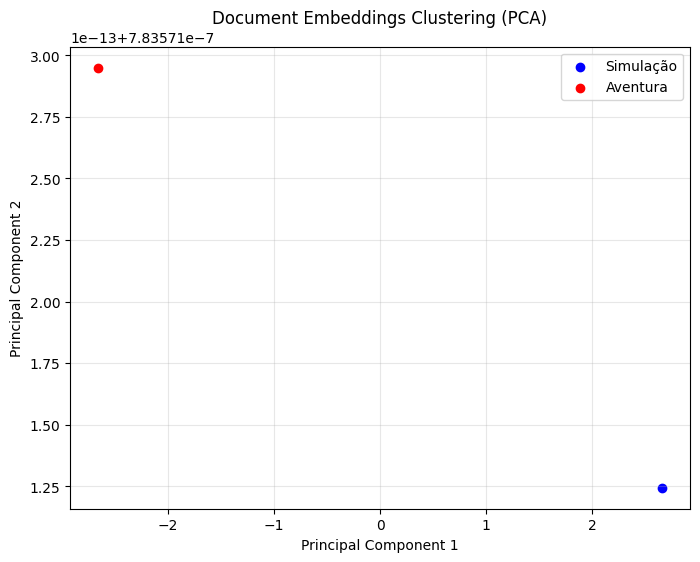

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. Define sample documents representing distinct topics
simulator_docs = [
"Um relaxante simulador de forja em pixel art. Colete materiais, aprimore suas ferramentas e crie armas lendárias sob encomenda para heróis e vilões.",
"Um simulador de jardinagem zen onde o objetivo é cultivar e descobrir espécies raras de plantas em um mundo mágico em constante mudança.",
"Um simulador de física e quebra-cabeças. Invada tumbas traiçoeiras cheias de armadilhas e colete artefatos valiosos sem ser esmagado.",
"Um simulador de quebra-cabeça. Receba robôs com defeito e conserte seus circuitos complexos e mecânica interna.",
"Um simulador de economia onde você compra, vende e troca mercadorias em uma movimentada cidade medieval.",
"Um simulador de sandbox de bruxaria. Crie feitiços, voe em sua vassoura e interaja com o mundo mágico.",
"Um simulador de escalada realista. Gerencie sua resistência, equipamentos e enfrente condições climáticas extremas para chegar ao topo.",
"Um simulador de vida. Frequente uma academia para jovens super-heróis, aprenda a usar seus poderes e socialize.",
"Um simulador de loja relaxante com um toque sobrenatural. Compre e venda antiguidades, algumas das quais vêm com seus próprios fantasmas.",
"Um simulador realista. Passe por um rigoroso treinamento espacial, desde testes de gravidade zero até caminhadas espaciais complexas."

]

advennture_docs = [
"Um jogo de aventura subaquática. Use equipamentos de alta tecnologia para explorar ruínas antigas e descobrir a verdade sobre a civilização perdida.",
"Um jogo de aventura e ação estilo Indiana Jones. Explore tumbas egípcias, resolva enigmas e escape de múmias.",
"Um jogo de aventura e gerenciamento. Explore um planeta distante para encontrar e resgatar animais alienígenas raros para o seu zoológico.",
"Um jogo de aventura de texto com elementos de ficção científica. Use um dispositivo quântico para explorar múltiplas realidades e resolver crimes.",
"Um jogo de aventura e exploração focado em história e mitologia em ruínas de uma civilização perdida."
]

all_docs = simulator_docs + advennture_docs 
labels = ["Simulação"] * len(simulator_docs) + ["Aventura"] * len(advennture_docs)
print(len(all_docs))
# 2. Extract embeddings
embeddings = []
for doc in all_docs:
    # get_embedding returns shape (1, d_model), take [0] to get (d_model,)
    emb = get_semantic_embedding(doc, model)
    embeddings.append(emb[0])

X = np.array(embeddings)

# 3. Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 4. Plot
plt.figure(figsize=(8, 6))
unique_labels = list(set(labels))
colors = ['blue', 'red']

for i, label in enumerate(unique_labels):
    indices = [j for j, x in enumerate(labels) if x == label]
    plt.scatter(X_pca[indices, 0], X_pca[indices, 1], c=colors[i], label=label)

plt.title("Document Embeddings Clustering (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()